In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

In [2]:
def load_santa_fe(path):
    """
    Load the Santa Fe competition datasets.
    """
    
    with open(path) as f:
        text = f.read()
    values = [v for v in text.replace("\n", ",").split(",") if v.strip()]
    return pd.DataFrame(values, columns=["intensity"])

In [3]:
# Load datasets.
sunspots = pd.read_csv("./Datasets/SN_m_tot_V2.0.csv", header=None, names=["year", "month", "decimal_date", "sunspot_number", "std_dev", "n_obs", "definitive"])
flights = pd.read_csv("./Datasets/airline-passengers.csv")
temperatures = pd.read_csv("./Datasets/daily-min-temperatures.csv", index_col=0, parse_dates=True)
mackey_glass = pd.read_csv("./Datasets/Mackey-Glass Time Series (taw17).csv", index_col=0)
santa_fe_train = load_santa_fe("./Datasets/Santa Fe/SF_A.dat")
santa_fe_test = load_santa_fe("./Datasets/Santa Fe/SF_Acont.dat")

# Data pre-processing

## Mackey-Glass data

In [27]:
def swap_columns(df, col1, col2):
    col_list = list(df.columns)
    x, y = col_list.index(col1), col_list.index(col2)
    col_list[y], col_list[x] = col_list[x], col_list[y]
    df = df[col_list]
    return df

In [28]:
# Swap t and t-tau columns and rename both.
mackey_glass_swapped = swap_columns(mackey_glass, "t", "t-tau")
mackey_glass_swapped.rename(columns={"t-tau": "t", "t": "t-tau", "t+1": "next_t"}, inplace=True)

In [29]:
# Recreate the dataset from only the t-column.
t = mackey_glass_swapped["t"]
mackey_glass_final = pd.DataFrame({
    "t": t,
    "t-tau": t.shift(17),    # t-value 17 steps ago -> NaN in first 17 rows
    "t_next": t.shift(-1),   # next t-value -> NaN in last row
})
mackey_glass_final = mackey_glass_final.dropna()             # keep only rows where every column is real

In [30]:
# Remove the first and last 17 rows since they contain a "0.0" value for t or t-tau due to padding.
mackey_glass_final = mackey_glass_final[1:-17]

In [43]:
mackey_glass_final.to_csv("mackey_glass_final.csv", index=False)

## Melbourne temperatures dataset

In [4]:
temperatures

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8
...,...
1990-12-27,14.0
1990-12-28,13.6
1990-12-29,13.5


In [5]:
# There are 2 missing dates in the dataset. We need to add them as rows with NaN values.
full_date_range = pd.date_range(temperatures.index.min(), temperatures.index.max(), freq="D")
temperatures = temperatures.reindex(full_date_range) # the two gaps now show up as NaN rows

In [6]:
# Forward fill both gaps.
temperatures["Temp"] = temperatures["Temp"].ffill()

In [7]:
temperatures.to_csv("./Pre-processed datasets/temperatures_final.csv")

## Flights dataset

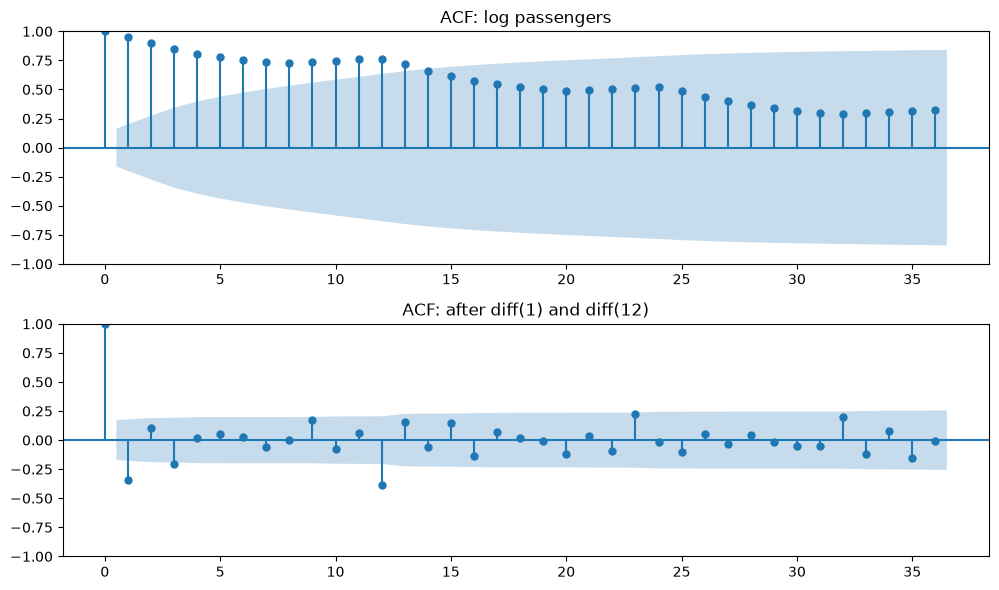

In [21]:
airline = pd.read_csv("./Datasets/airline-passengers.csv", index_col=0, parse_dates=True)

log_p = np.log(airline["Passengers"])
y = log_p.diff().diff(12).dropna()        # dropna matters: plot_acf fails on NaNs

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(log_p, lags=36, ax=axes[0], title="ACF: log passengers")
plot_acf(y,     lags=36, ax=axes[1], title="ACF: after diff(1) and diff(12)")
plt.tight_layout()
plt.show()

In [15]:
# Log-transform the column to minimize trend.
# Diff the column to remove the trend.
# Diff the columns with a value of 12 to encode the information of the yearly change in passengers.
y = np.log(flights["Passengers"]).diff().diff(12).dropna()
flights["Passengers"] = y
flights.dropna(inplace=True)

In [22]:
flights.to_csv("flights_final.csv", index=False)

## Sunspots dataset

In [112]:
# Build a monthly DatetimeIndex from the year and month columns.
sunspots.index = pd.to_datetime(
    dict(year=sunspots["year"], month=sunspots["month"], day=1)
)
sunspots.index.name = "date"

In [113]:
# Checks: real dates, no gaps, in order.
print(sunspots.index.dtype)                        # datetime64
full = pd.date_range(sunspots.index.min(), sunspots.index.max(), freq="MS")
print(len(full) - len(sunspots))                   # 0 → no missing months
print(sunspots.index.is_monotonic_increasing)      # True

datetime64[us]
0
True


In [114]:
# Drop the provisional months and final incomplete year.
sunspots = sunspots[sunspots["definitive"] == 1]
sunspots = sunspots[sunspots["year"] != 2026]
sn = sunspots["sunspot_number"]

# Resample to yearly means.
yearly = sn.resample("YS").mean()
yearly_t = np.sqrt(yearly)

print(len(yearly), yearly.index.min(), yearly.index.max())

277 1749-01-01 00:00:00 2025-01-01 00:00:00


In [115]:
sunspots_final = pd.DataFrame(yearly)
sunspots_final.rename(columns={"sunspot_number": "sn_avg"}, inplace=True)

In [116]:
sunspots_final.to_csv("./Pre-processed datasets/sunspots/sunspots_final.csv")

## Santa Fe laser dataset

In [127]:
santa_fe_train["intensity"] = santa_fe_train["intensity"].astype(int)
santa_fe_test["intensity"] = santa_fe_test["intensity"].astype(int)

In [128]:
santa_fe_train["intensity"] = santa_fe_train["intensity"]/255
santa_fe_test["intensity"] = santa_fe_test["intensity"]/255

In [131]:
santa_fe_train.to_csv("santa_fe_train_final")
santa_fe_test.to_csv("santa_fe_test_final")